## HW01

### 2 概述、线性代数和 NDArray

#### 2.1 理论计算题

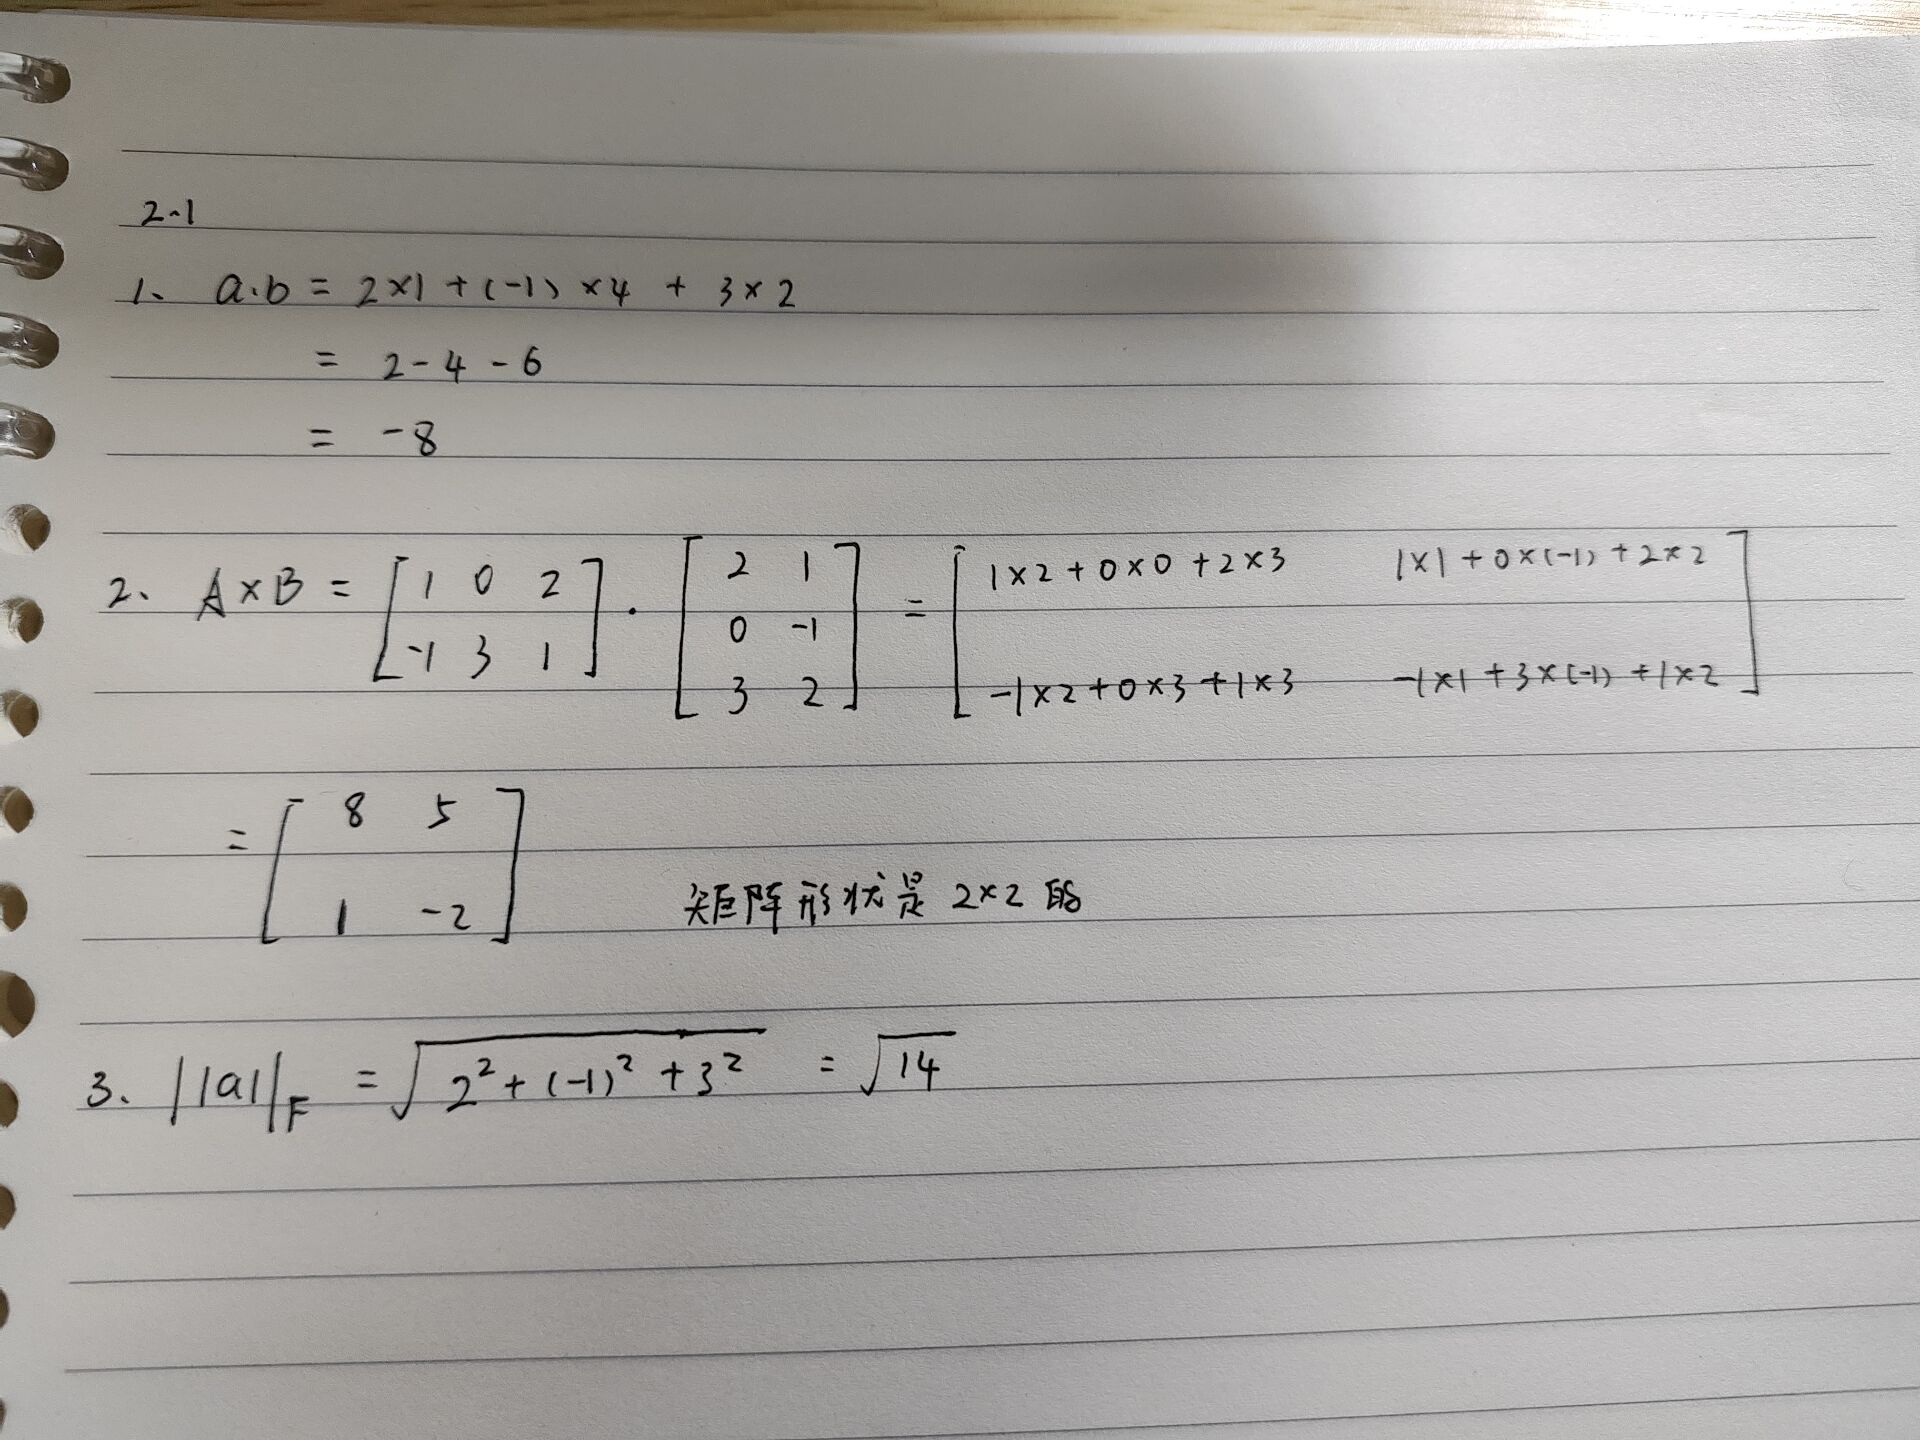

#### 2.2 编程题

In [1]:
import numpy as np

# 1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("矩阵 X:")
print(X)
print()

# 2. 创建一个形状为 4 × 2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("矩阵 Y:")
print(Y)
print()

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("矩阵 Z = X × Y:")
print(Z)
print()

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
print("Z[0, 1] (第一行第二列):", Z[0, 1])
print("Z 的第 2 行所有元素:", Z[1])
print()

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z)
print("Z 的 Frobenius 范数:", frobenius_norm)

矩阵 X:
[[ 0.62192167  0.22316504  0.10442243  0.14517734]
 [ 1.75163276 -0.90389736  0.17098996 -1.10244522]
 [-0.06715693  0.17512498 -1.16581405 -1.46150575]]

矩阵 Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z = X × Y:
[[ 1.09468649  1.09468649]
 [-0.08371986 -0.08371986]
 [-2.51935176 -2.51935176]]

Z[0, 1] (第一行第二列): 1.094686488480536
Z 的第 2 行所有元素: [-0.08371986 -0.08371986]

Z 的 Frobenius 范数: 3.8865102062784174


### 3 文档 2：概率与统计


#### 3.1 理论计算题

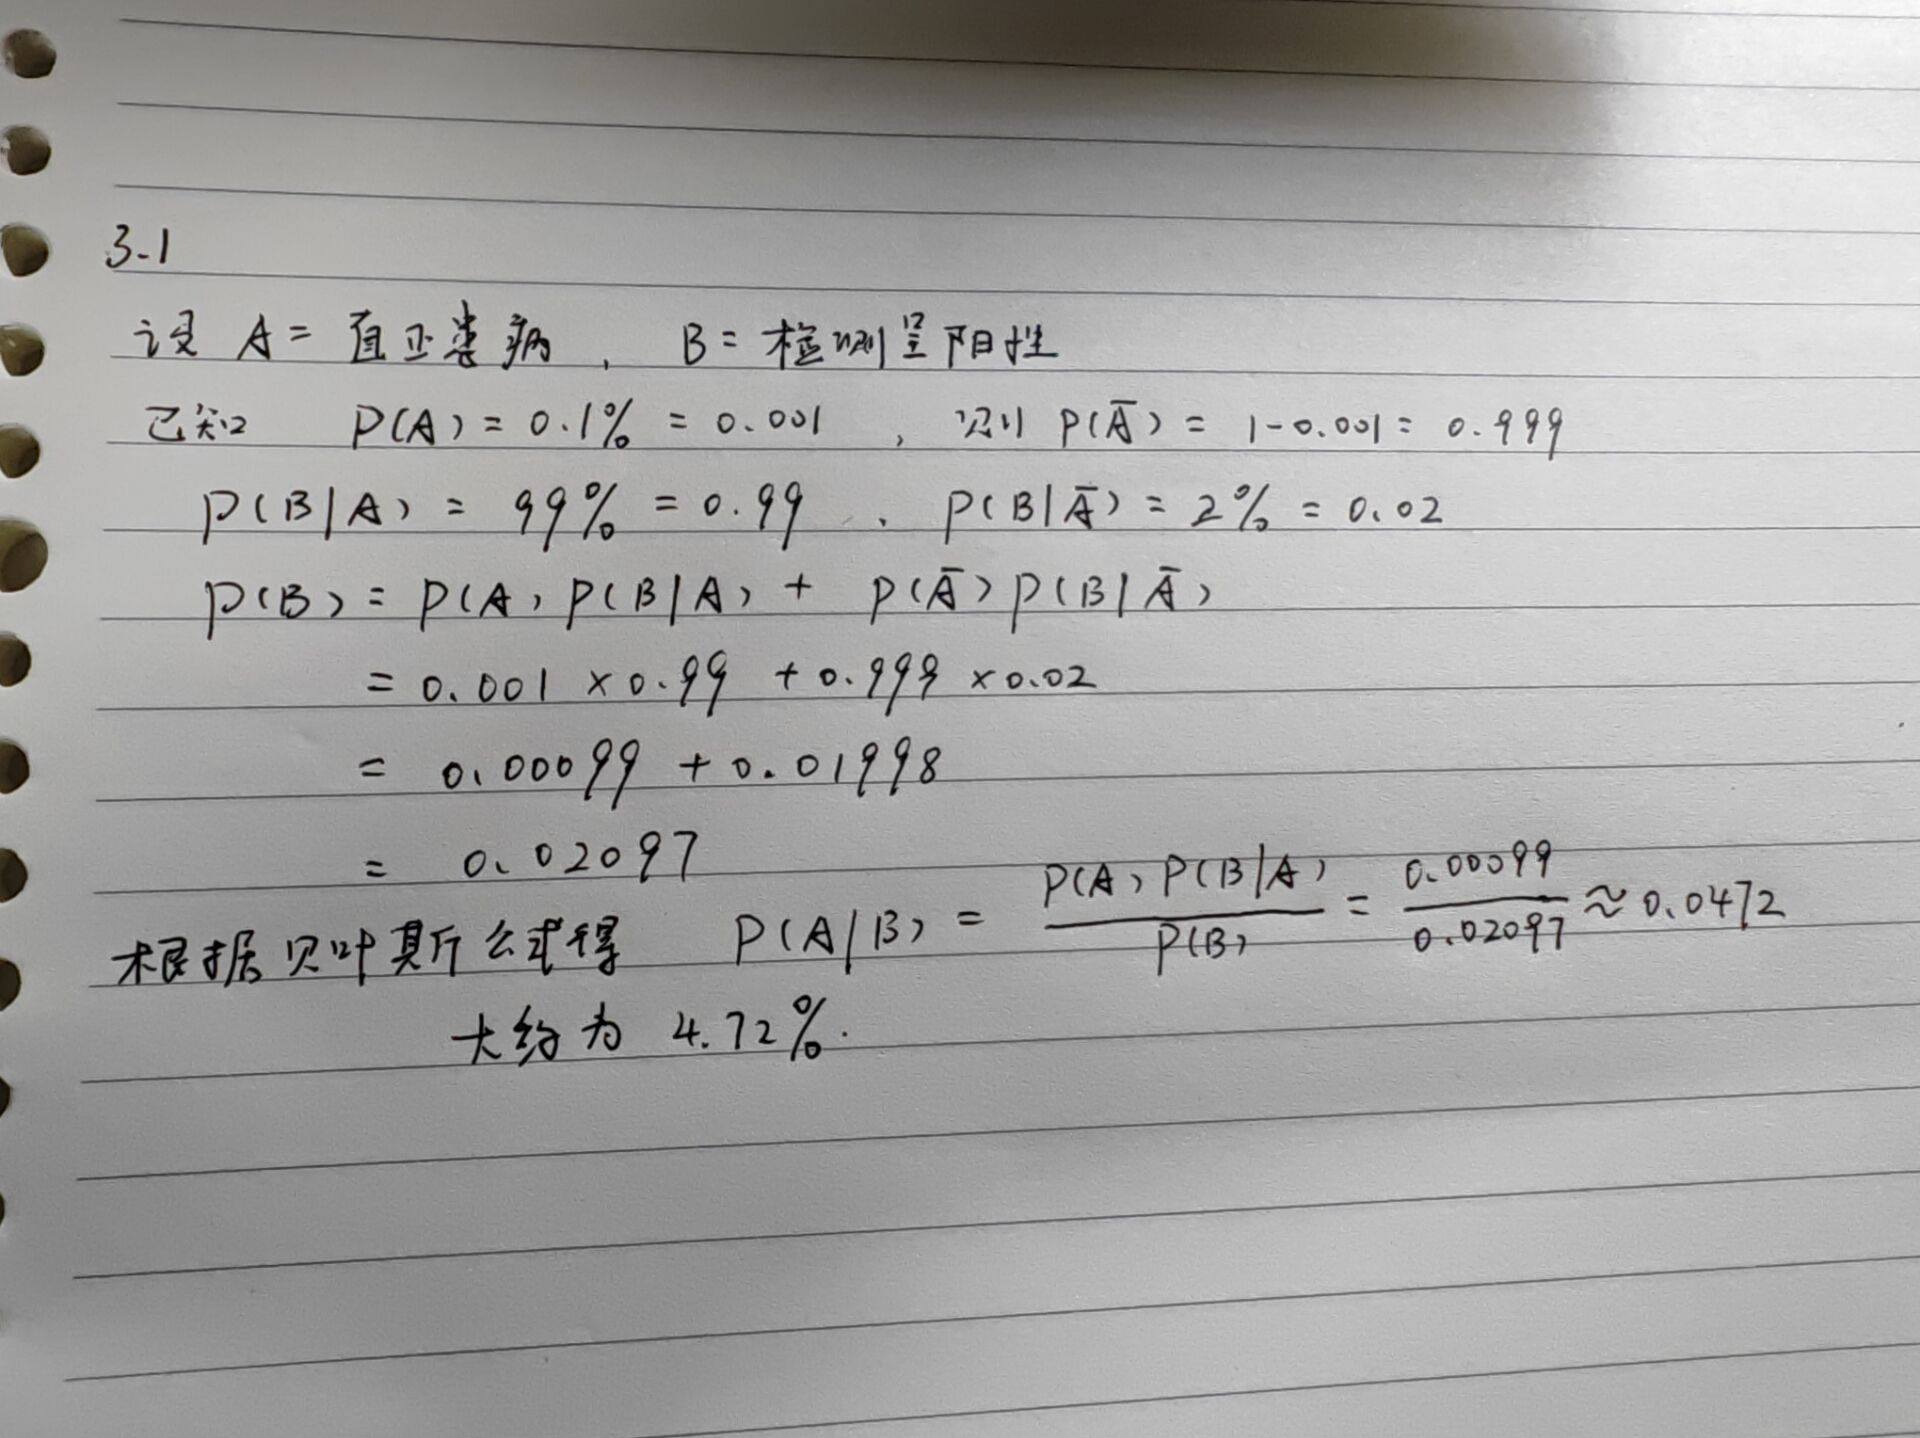

#### 3.2 编程题


e:\Anaconda3\envs\test\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3\envs\test\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3\envs\test\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3\envs\test\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3\envs\test\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


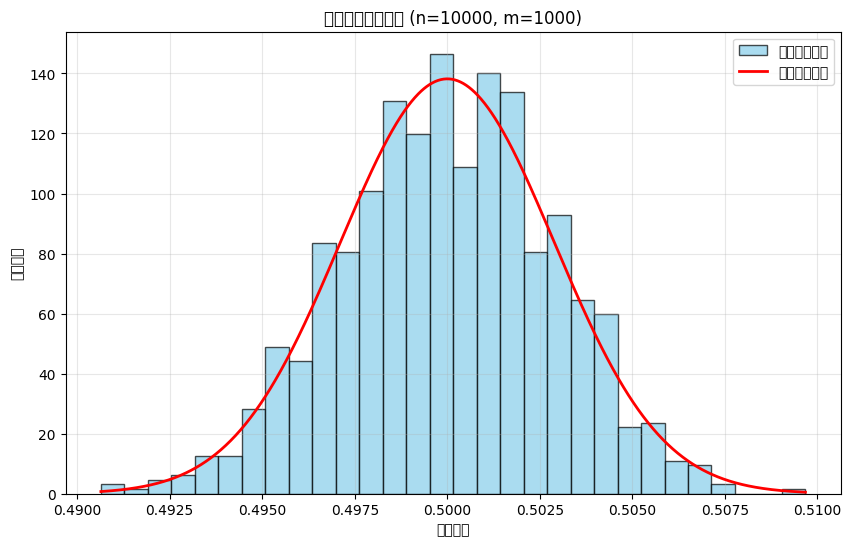

实际方差: 0.000008
实际标准差: 0.002875
理论方差: 0.000008
理论标准差: 0.002887

实际方差与理论方差之比: 0.9917


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置参数
n = 10000  # 每次抽样的样本数量
m = 1000   # 重复实验次数

# 1. 生成n=10000个服从均匀分布U(0,1)的随机变量，重复m=1000次，每次计算均值
means = []
for i in range(m):
    # 生成n个均匀分布随机变量
    samples = np.random.uniform(0, 1, n)
    # 计算均值
    sample_mean = np.mean(samples)
    means.append(sample_mean)

means = np.array(means)

# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))

# 绘制直方图
n_bins = 30
plt.hist(means, bins=n_bins, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label='样本均值分布')

# 计算理论正态分布参数
# 根据中心极限定理，样本均值服从N(μ, σ²/n)
# 对于U(0,1)分布：μ=0.5, σ²=1/12
mu_theoretical = 0.5  # 均匀分布的期望
sigma_theoretical = np.sqrt(1/12/n)  # 理论标准差

# 生成理论正态分布曲线
x = np.linspace(min(means), max(means), 1000)
plt.plot(x, norm.pdf(x, mu_theoretical, sigma_theoretical), 
         'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证 (n=10000, m=1000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. 计算实际方差
actual_variance = np.var(means)
actual_std = np.std(means)

print(f"实际方差: {actual_variance:.6f}")
print(f"实际标准差: {actual_std:.6f}")
print(f"理论方差: {1/(12*n):.6f}")
print(f"理论标准差: {sigma_theoretical:.6f}")

# 比较实际与理论值
print(f"\n实际方差与理论方差之比: {actual_variance/(1/(12*n)):.4f}")

### 4 文档 3：导数、反向传播和复杂度
#### 4.1 理论计算题

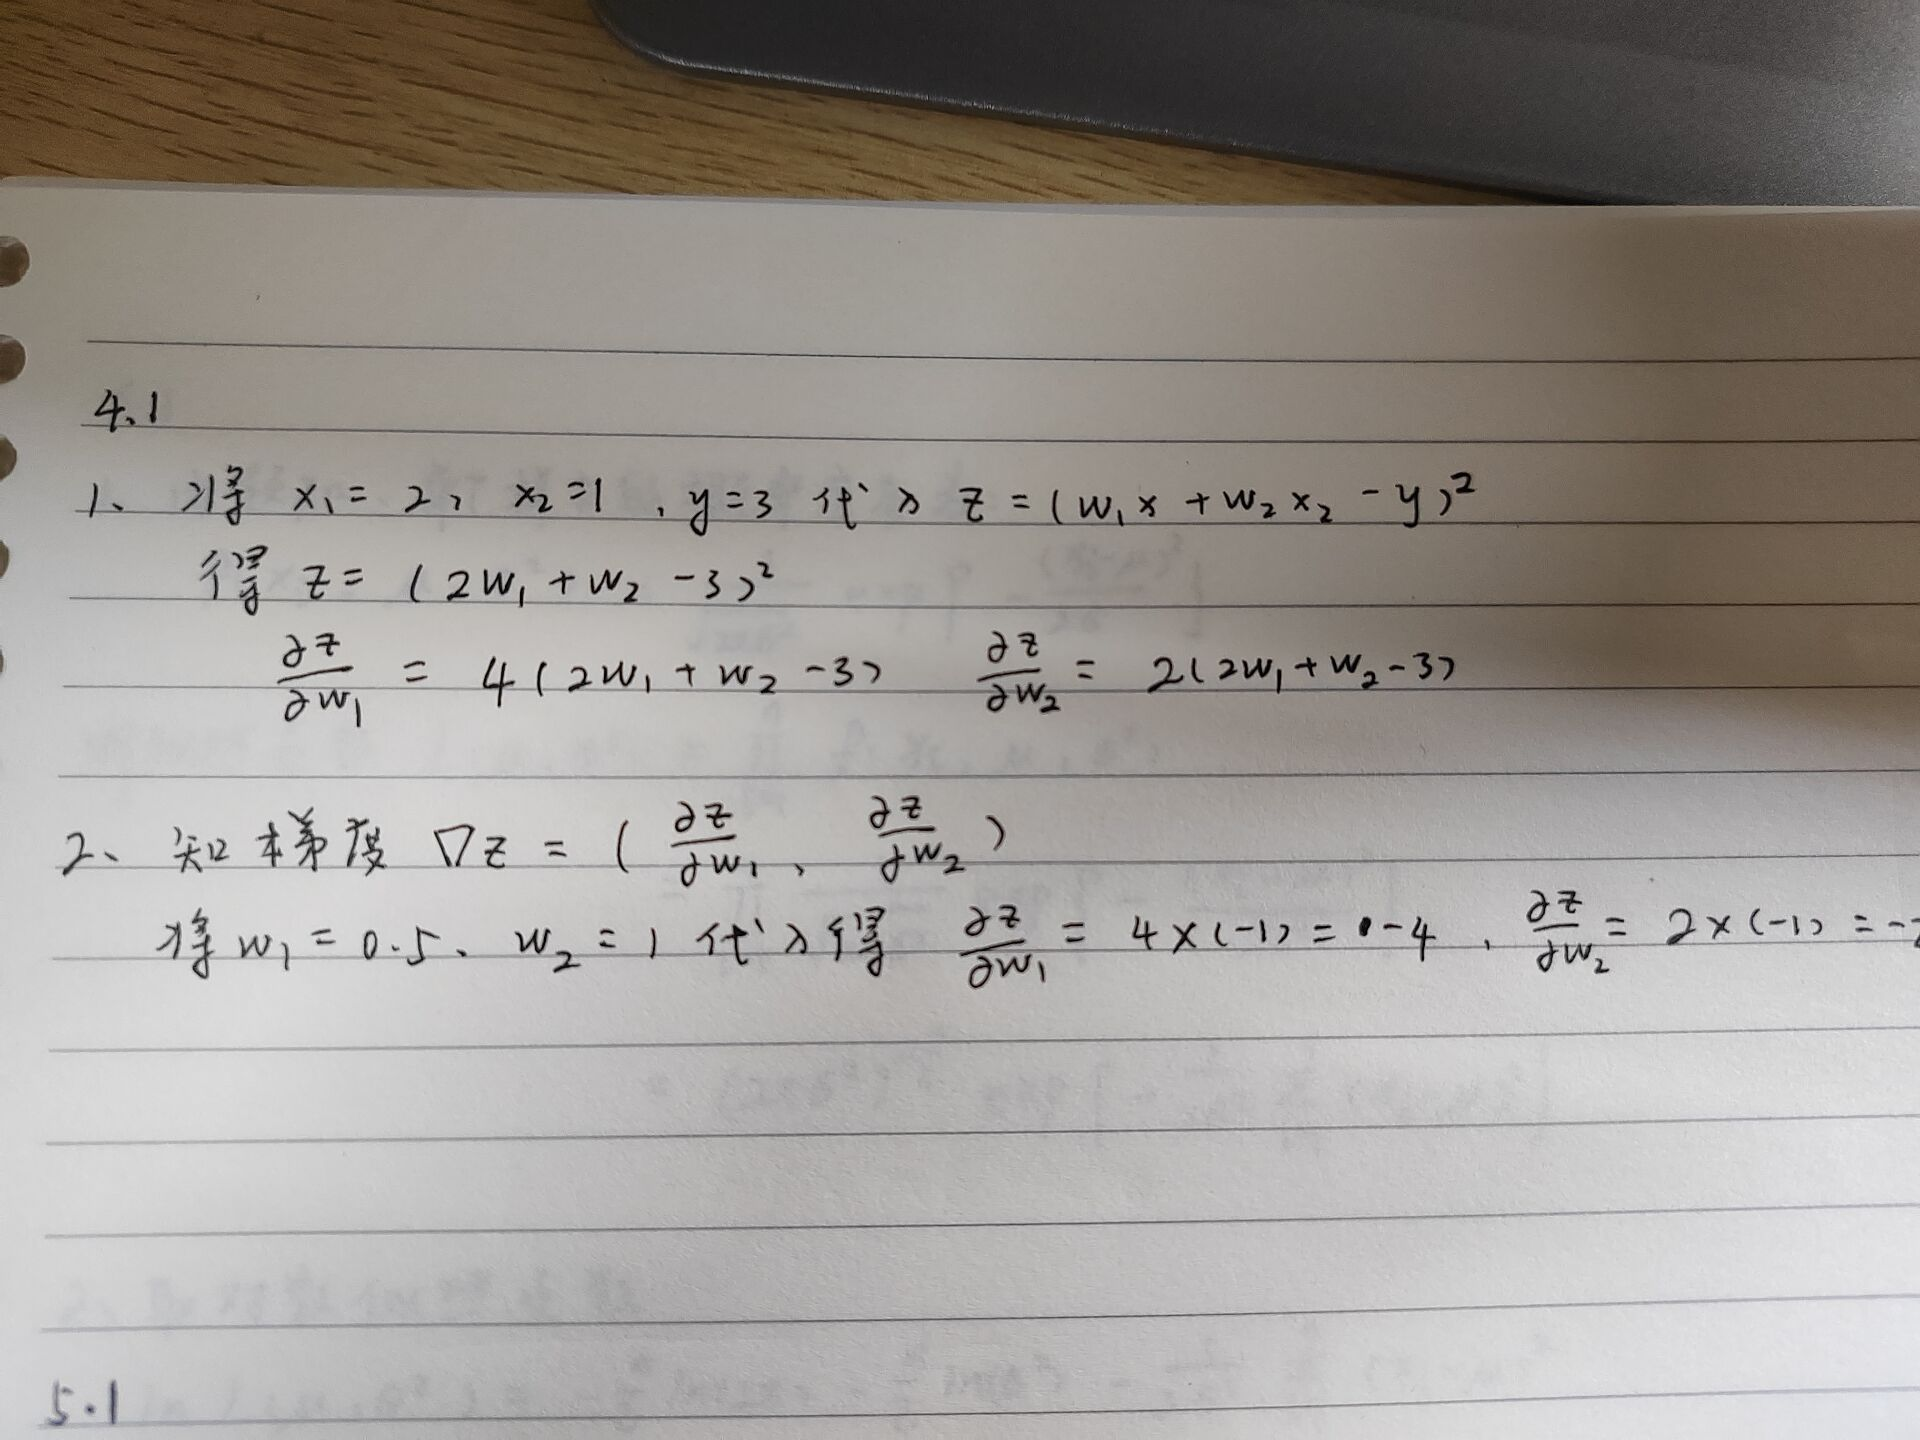

#### 4.2 编程题

In [3]:
import torch

# 1. 定义前向计算函数
def forward(x, w1, w2):
    """前向计算：a = x * w1, b = a + w2, L = b^2"""
    a = x * w1
    b = a + w2
    L = b ** 2
    return a, b, L

# 2. 给定参数并计算前向结果
x = 2.0
w1 = 1.5
w2 = 0.5

a, b, L = forward(x, w1, w2)
print("前向计算结果：")
print(f"a = x * w1 = {x} * {w1} = {a}")
print(f"b = a + w2 = {a} + {w2} = {b}")
print(f"L = b^2 = {b}^2 = {L}")
print()

# 3. 手动计算梯度（链式法则）
print("手动计算梯度：")

# 计算各节点的局部梯度
dL_db = 2 * b  # ∂L/∂b = 2b
db_da = 1.0   # ∂b/∂a = 1
db_dw2 = 1.0  # ∂b/∂w2 = 1
da_dw1 = x    # ∂a/∂w1 = x
da_dx = w1    # ∂a/∂x = w1

# 计算最终梯度
dL_dw1 = dL_db * db_da * da_dw1  # ∂L/∂w1 = ∂L/∂b * ∂b/∂a * ∂a/∂w1
dL_dw2 = dL_db * db_dw2          # ∂L/∂w2 = ∂L/∂b * ∂b/∂w2
dL_dx = dL_db * db_da * da_dx    # ∂L/∂x = ∂L/∂b * ∂b/∂a * ∂a/∂x

print(f"∂L/∂b = 2b = 2 * {b} = {dL_db}")
print(f"∂b/∂a = 1")
print(f"∂b/∂w2 = 1")
print(f"∂a/∂w1 = x = {x}")
print(f"∂a/∂x = w1 = {w1}")
print()
print(f"∂L/∂w1 = ∂L/∂b * ∂b/∂a * ∂a/∂w1 = {dL_db} * 1 * {x} = {dL_dw1}")
print(f"∂L/∂w2 = ∂L/∂b * ∂b/∂w2 = {dL_db} * 1 = {dL_dw2}")
print(f"∂L/∂x = ∂L/∂b * ∂b/∂a * ∂a/∂x = {dL_db} * 1 * {w1} = {dL_dx}")
print()

# 4. 使用PyTorch自动微分验证
print("使用PyTorch自动微分验证：")

# 创建需要梯度的张量
x_tensor = torch.tensor([x], requires_grad=True)
w1_tensor = torch.tensor([w1], requires_grad=True)
w2_tensor = torch.tensor([w2], requires_grad=True)

# 前向计算
a_tensor = x_tensor * w1_tensor
b_tensor = a_tensor + w2_tensor
L_tensor = b_tensor ** 2

# 反向传播
L_tensor.backward()

print(f"PyTorch ∂L/∂w1: {w1_tensor.grad.item()}")
print(f"PyTorch ∂L/∂w2: {w2_tensor.grad.item()}")
print(f"PyTorch ∂L/∂x: {x_tensor.grad.item()}")
print()

# 5. 验证结果是否一致
print("结果验证：")
print(f"手动计算 ∂L/∂w1 = {dL_dw1}, PyTorch结果 = {w1_tensor.grad.item()}")
print(f"是否一致: {abs(dL_dw1 - w1_tensor.grad.item()) < 1e-10}")
print()
print(f"手动计算 ∂L/∂w2 = {dL_dw2}, PyTorch结果 = {w2_tensor.grad.item()}")
print(f"是否一致: {abs(dL_dw2 - w2_tensor.grad.item()) < 1e-10}")
print()
print(f"手动计算 ∂L/∂x = {dL_dx}, PyTorch结果 = {x_tensor.grad.item()}")
print(f"是否一致: {abs(dL_dx - x_tensor.grad.item()) < 1e-10}")

前向计算结果：
a = x * w1 = 2.0 * 1.5 = 3.0
b = a + w2 = 3.0 + 0.5 = 3.5
L = b^2 = 3.5^2 = 12.25

手动计算梯度：
∂L/∂b = 2b = 2 * 3.5 = 7.0
∂b/∂a = 1
∂b/∂w2 = 1
∂a/∂w1 = x = 2.0
∂a/∂x = w1 = 1.5

∂L/∂w1 = ∂L/∂b * ∂b/∂a * ∂a/∂w1 = 7.0 * 1 * 2.0 = 14.0
∂L/∂w2 = ∂L/∂b * ∂b/∂w2 = 7.0 * 1 = 7.0
∂L/∂x = ∂L/∂b * ∂b/∂a * ∂a/∂x = 7.0 * 1 * 1.5 = 10.5

使用PyTorch自动微分验证：
PyTorch ∂L/∂w1: 14.0
PyTorch ∂L/∂w2: 7.0
PyTorch ∂L/∂x: 10.5

结果验证：
手动计算 ∂L/∂w1 = 14.0, PyTorch结果 = 14.0
是否一致: True

手动计算 ∂L/∂w2 = 7.0, PyTorch结果 = 7.0
是否一致: True

手动计算 ∂L/∂x = 10.5, PyTorch结果 = 10.5
是否一致: True


### 5 文档 4：线性方法、基础优化和 softmax 回归
#### 5.1 理论计算题


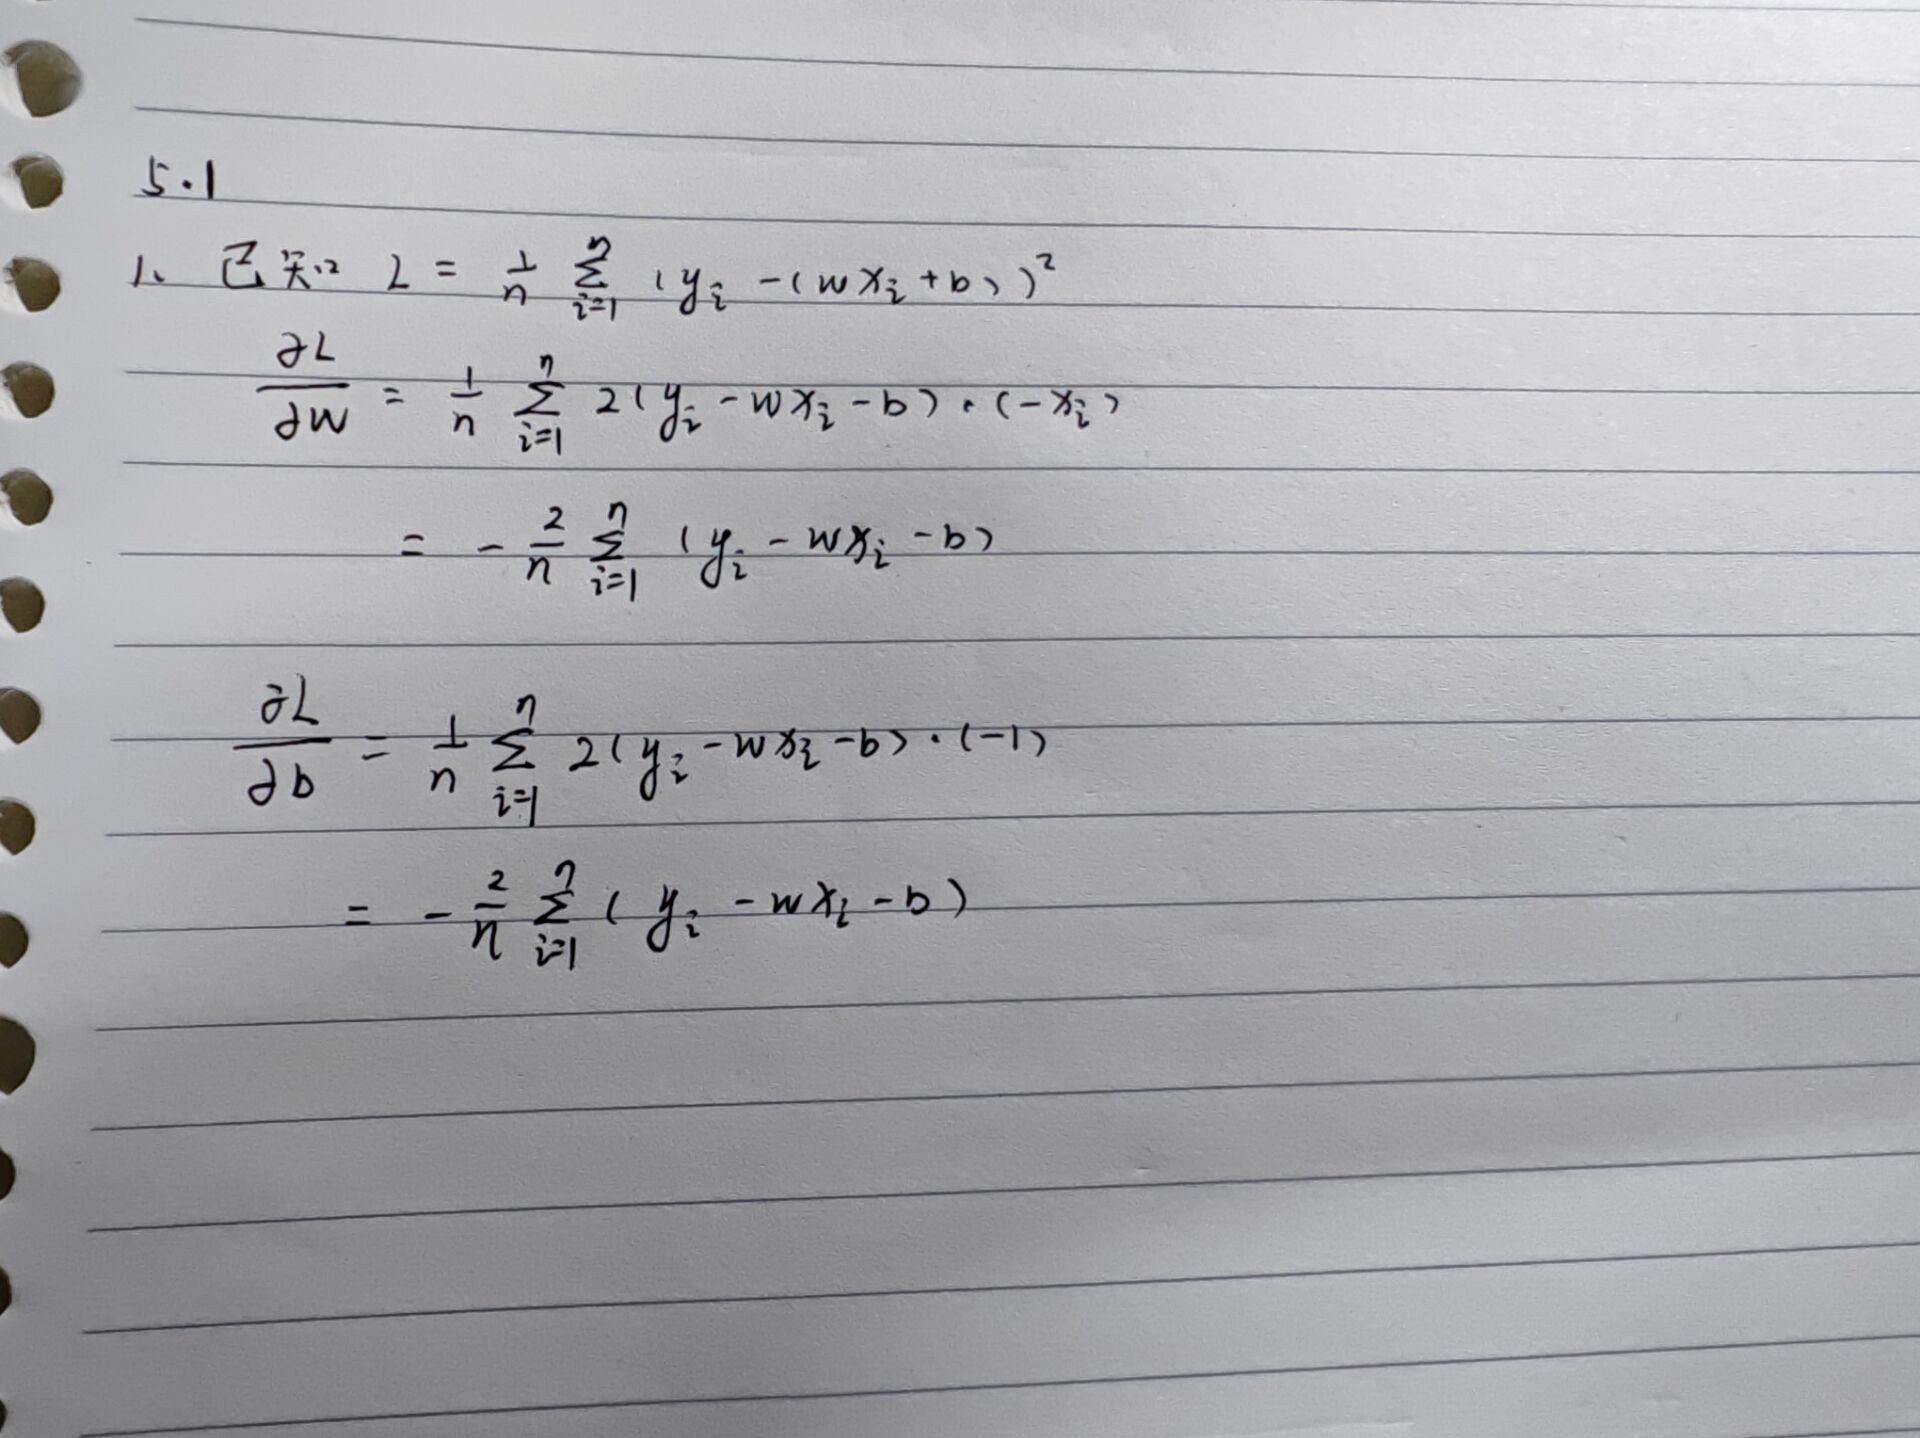

#### 5.2 编程题

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据集
print("加载数据集...")
digits = load_digits()
X = digits.data  # 8x8 图像展平为 64 维向量
y = digits.target.reshape(-1, 1)  # 标签

# 2. 数据预处理
print("数据预处理...")
# 归一化（可选，这里数据已经是0-16，我们归一化到0-1）
X = X / 16.0

# 分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot 编码标签
encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"类别数: {y_train_onehot.shape[1]}")

# 3. 实现 softmax 函数和交叉熵损失函数
def softmax(z):
    """softmax 函数，处理数值稳定性"""
    # 减去最大值防止溢出
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失函数"""
    # 防止log(0)
    epsilon = 1e-10
    return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

def compute_gradient(X, y_true, y_pred, W, b):
    """计算梯度"""
    m = X.shape[0]
    # 梯度计算
    dZ = y_pred - y_true
    dW = (1/m) * np.dot(X.T, dZ)
    db = (1/m) * np.sum(dZ, axis=0, keepdims=True)
    return dW, db

# 4. 模型初始化和训练
print("初始化模型...")
# 超参数
batch_size = 32
learning_rate = 0.1
epochs = 50
input_dim = X_train.shape[1]
output_dim = y_train_onehot.shape[1]

# 初始化参数
np.random.seed(42)
W = np.random.randn(input_dim, output_dim) * 0.01
b = np.zeros((1, output_dim))

# 训练过程
print("开始训练...")
for epoch in range(epochs):
    # 小批量随机梯度下降
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    total_loss = 0
    for i in range(0, X_train.shape[0], batch_size):
        # 取批量数据
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        Z = np.dot(X_batch, W) + b
        y_pred = softmax(Z)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        total_loss += loss
        
        # 反向传播计算梯度
        dW, db = compute_gradient(X_batch, y_batch, y_pred, W, b)
        
        # 更新参数
        W -= learning_rate * dW
        b -= learning_rate * db
    
    # 打印每轮损失
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/(X_train.shape[0]/batch_size):.4f}")

# 5. 测试模型
print("测试模型...")
# 前向传播计算测试集预测
Z_test = np.dot(X_test, W) + b
y_test_pred = softmax(Z_test)
# 转换为类别
y_test_pred_class = np.argmax(y_test_pred, axis=1)
y_test_true_class = np.argmax(y_test_onehot, axis=1)

# 计算准确率
accuracy = np.mean(y_test_pred_class == y_test_true_class)
print(f"测试集准确率: {accuracy:.4f}")

加载数据集...
数据预处理...
训练集大小: (1437, 64)
测试集大小: (360, 64)
类别数: 10
初始化模型...
开始训练...
Epoch 5/50, Loss: 0.7381
Epoch 10/50, Loss: 0.4583
Epoch 15/50, Loss: 0.3558
Epoch 20/50, Loss: 0.3010
Epoch 25/50, Loss: 0.2661
Epoch 30/50, Loss: 0.2409
Epoch 35/50, Loss: 0.2230
Epoch 40/50, Loss: 0.2083
Epoch 45/50, Loss: 0.1963
Epoch 50/50, Loss: 0.1863
测试模型...
测试集准确率: 0.9583


### 6 文档 5：最大似然估计和逻辑回归
#### 6.1 理论计算题


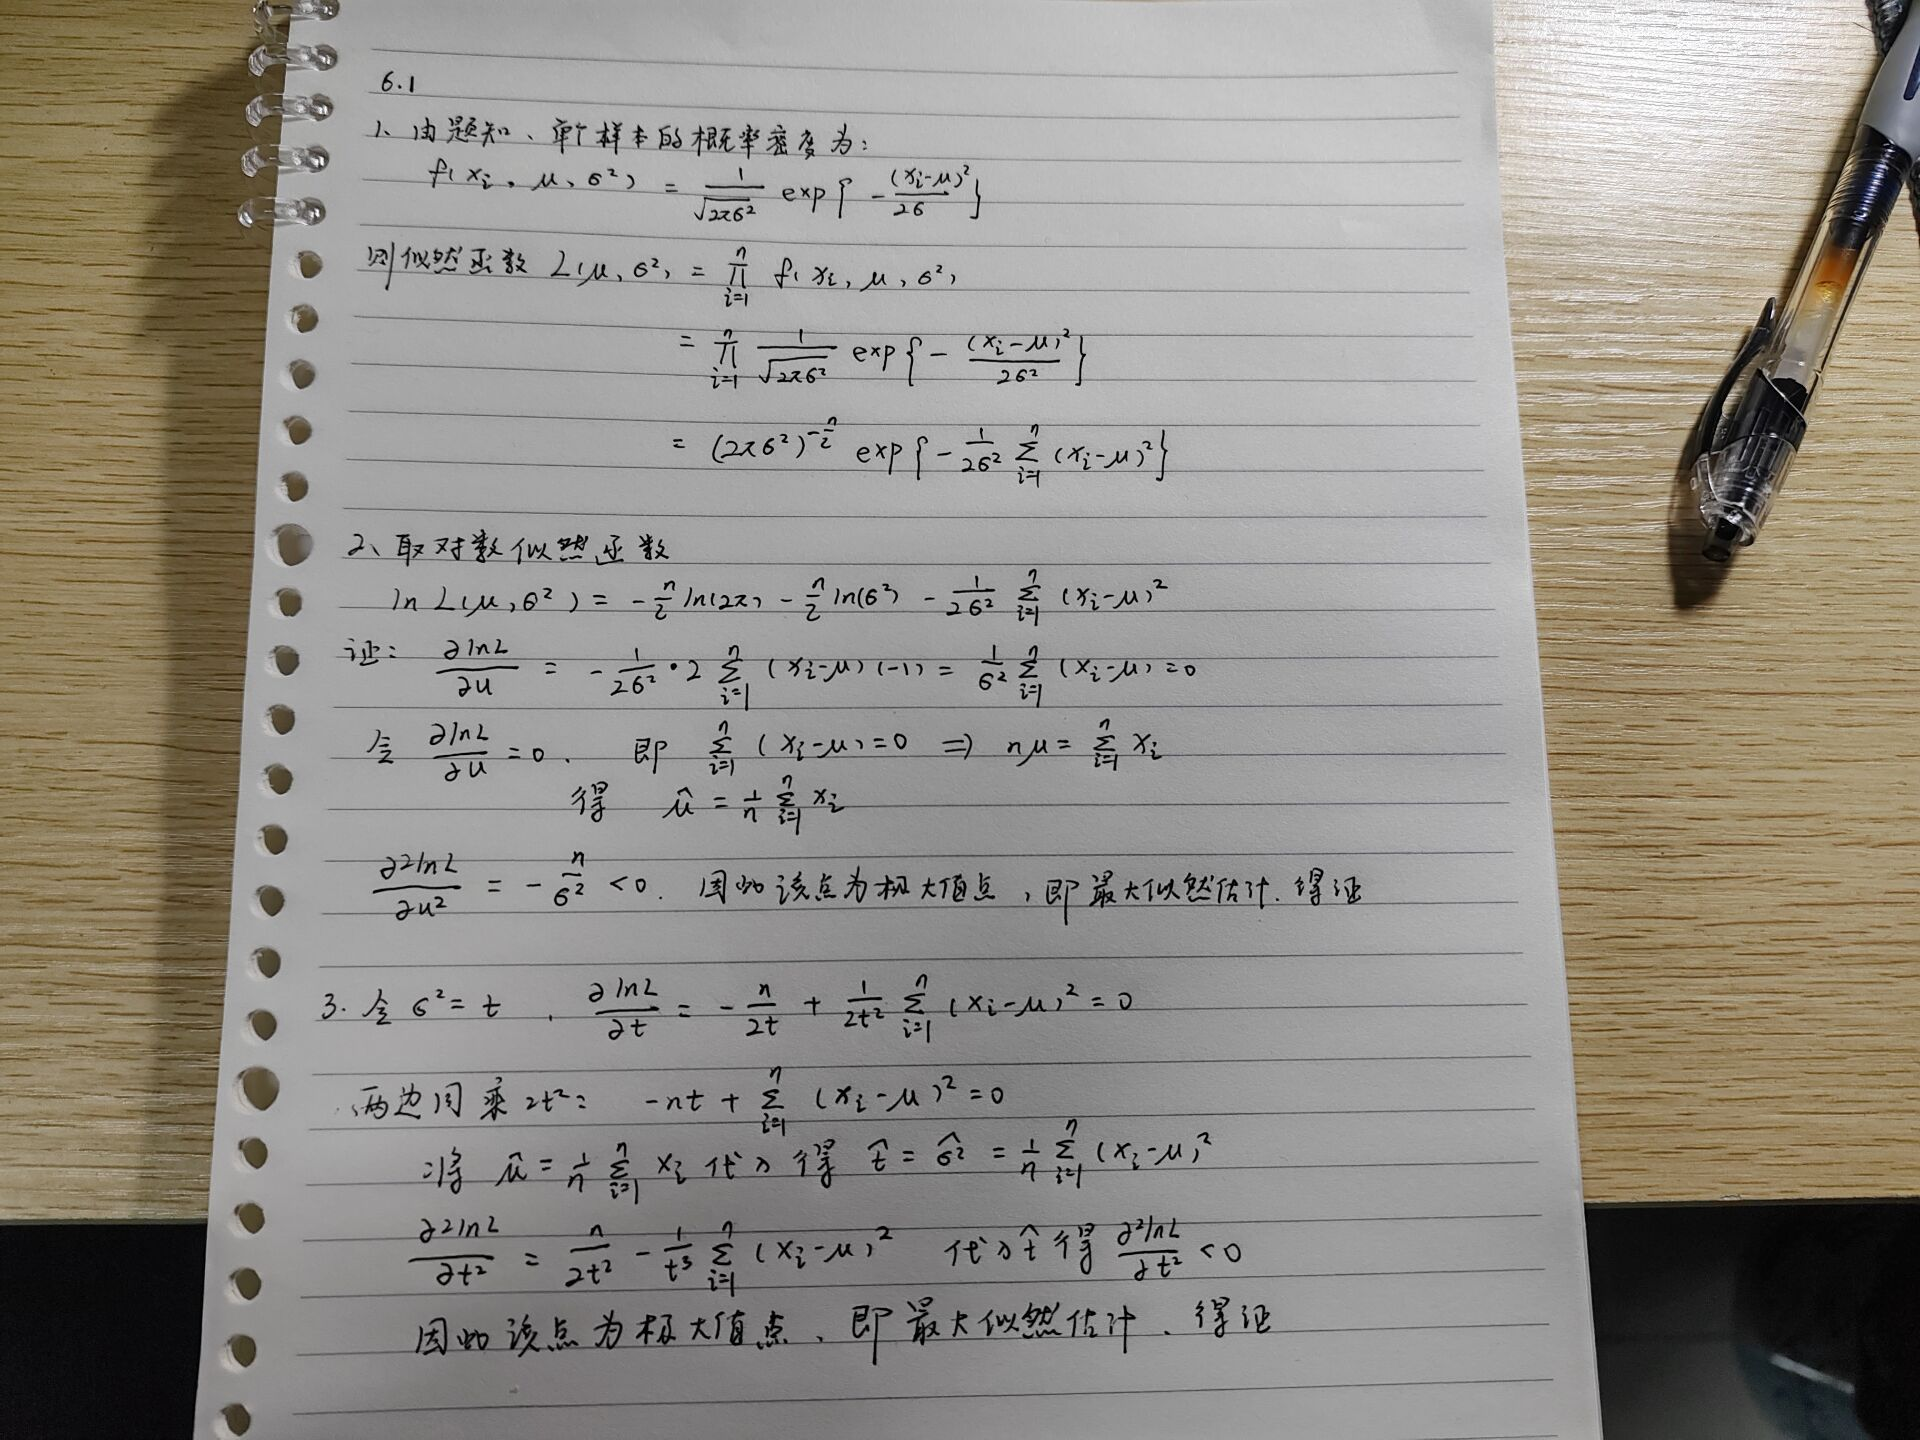

#### 6.2 编程题

生成训练数据...
训练数据形状: (400, 2)
标签形状: (400,)

训练模型...
Epoch 100/1000, Loss: 0.4168
Epoch 200/1000, Loss: 0.3093
Epoch 300/1000, Loss: 0.2471
Epoch 400/1000, Loss: 0.2072
Epoch 500/1000, Loss: 0.1796
Epoch 600/1000, Loss: 0.1594
Epoch 700/1000, Loss: 0.1440
Epoch 800/1000, Loss: 0.1318
Epoch 900/1000, Loss: 0.1219
Epoch 1000/1000, Loss: 0.1137

训练完成!
权重 w: [0.74205992 0.77223195]
偏置 b: -6.102797657956408

绘制决策边界...


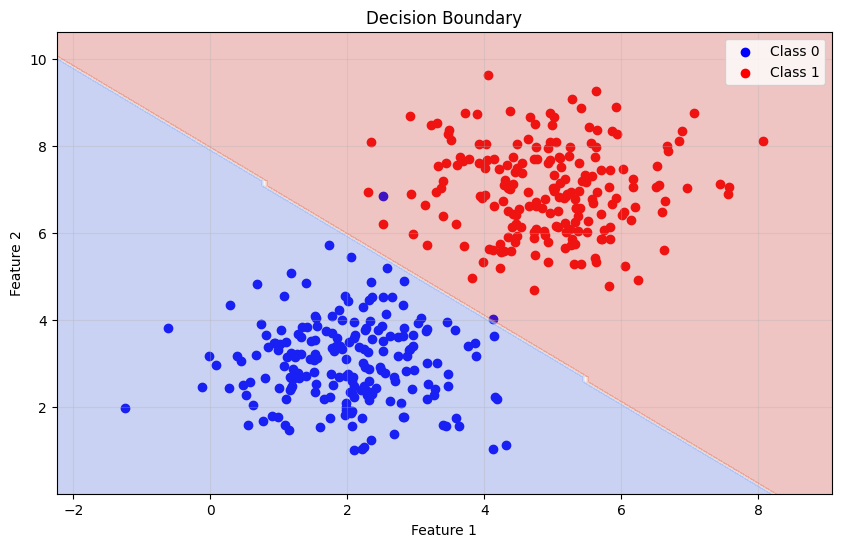


生成测试数据...
测试数据形状: (200, 2)
测试集准确率: 0.9950


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分的数据
def generate_data(n_samples=200):
    """生成两类线性可分的数据"""
    np.random.seed(42)
    
    # 第一类数据
    mean1 = [2, 3]
    cov1 = [[1, 0], [0, 1]]
    class1 = np.random.multivariate_normal(mean1, cov1, n_samples)
    labels1 = np.zeros(n_samples)
    
    # 第二类数据
    mean2 = [5, 7]
    cov2 = [[1, 0], [0, 1]]
    class2 = np.random.multivariate_normal(mean2, cov2, n_samples)
    labels2 = np.ones(n_samples)
    
    # 合并数据
    X = np.vstack((class1, class2))
    y = np.hstack((labels1, labels2))
    
    # 打乱数据
    indices = np.random.permutation(X.shape[0])
    X = X[indices]
    y = y[indices]
    
    return X, y

# 2. 定义sigmoid函数和二元交叉熵损失
def sigmoid(z):
    """sigmoid函数"""
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    """二元交叉熵损失"""
    epsilon = 1e-10
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

def compute_gradient(X, y, y_pred, w, b):
    """计算梯度"""
    m = X.shape[0]
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)
    return dw, db

# 3. 训练模型
def train_logistic_regression(X, y, learning_rate=0.1, epochs=1000):
    """训练逻辑回归模型"""
    m, n = X.shape
    # 初始化参数
    w = np.zeros(n)
    b = 0
    
    loss_history = []
    
    for epoch in range(epochs):
        # 前向传播
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        
        # 计算损失
        loss = binary_cross_entropy(y_pred, y)
        loss_history.append(loss)
        
        # 计算梯度
        dw, db = compute_gradient(X, y, y_pred, w, b)
        
        # 更新参数
        w -= learning_rate * dw
        b -= learning_rate * db
        
        # 每100个epoch打印一次
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
    
    return w, b, loss_history

# 4. 预测函数
def predict(X, w, b, threshold=0.5):
    """预测函数"""
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    return (y_pred >= threshold).astype(int)

# 5. 绘制决策边界
def plot_decision_boundary(X, y, w, b):
    """绘制决策边界"""
    plt.figure(figsize=(10, 6))
    
    # 绘制数据点
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, w, b)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 主函数
if __name__ == "__main__":
    # 生成训练数据
    print("生成训练数据...")
    X_train, y_train = generate_data(200)
    print(f"训练数据形状: {X_train.shape}")
    print(f"标签形状: {y_train.shape}")
    
    # 训练模型
    print("\n训练模型...")
    w, b, loss_history = train_logistic_regression(X_train, y_train, learning_rate=0.1, epochs=1000)
    print(f"\n训练完成!")
    print(f"权重 w: {w}")
    print(f"偏置 b: {b}")
    
    # 绘制决策边界
    print("\n绘制决策边界...")
    plot_decision_boundary(X_train, y_train, w, b)
    
    # 生成测试数据
    print("\n生成测试数据...")
    X_test, y_test = generate_data(100)
    print(f"测试数据形状: {X_test.shape}")
    
    # 预测并计算准确率
    y_pred = predict(X_test, w, b)
    accuracy = np.mean(y_pred == y_test)
    print(f"测试集准确率: {accuracy:.4f}")